# DSP 기초 실습

이 파일은 `Digital Signal Processing 1.pdf` 내용을 바탕으로 만든 **초급자용 실습 노트북**입니다.
어려운 이론을 모두 외우기보다는, 코드에서 만든 숫자 배열이 어떤 DSP 수식에 대응되는지 확인하면서 파형, 소리, 주파수 그림을 보는 데 집중합니다.

## 오늘 할 것

1. 소리를 숫자 배열로 만들고 들어보기
2. 샘플링, 정규화, 양자화 이해하기
3. FFT와 간단한 spectrogram 보기
4. 마지막에 GitHub에 올리는 방법 익히기

## 기호를 읽는 방법

- $x[n]$: 컴퓨터에 저장된 디지털 신호의 $n$번째 샘플입니다. 코드에서는 보통 `x`, `x_test`, `x_mix` 같은 배열입니다.
- $f_s$: sampling rate입니다. 코드에서는 `sr` 또는 `sr_test`입니다.
- $T_s = 1/f_s$: 샘플 하나 사이의 시간 간격입니다.
- $N$: 전체 샘플 개수입니다. 코드에서는 `len(x)`처럼 확인합니다.
- $f_0$: 만들고 싶은 사인파의 주파수입니다. 코드에서는 `freq`입니다.

<details>
<summary>실습 방법</summary>

- 셀을 위에서 아래로 차례대로 실행합니다.
- 코드가 길어 보여도 수정할 부분은 많지 않습니다.
- 그래프가 나오면 x축과 y축 이름을 먼저 봅니다.
- 소리 재생 버튼이 나오면 직접 들어봅니다.
- 수식 옆의 코드 변수 이름을 같이 보면서, 수식이 실제 코드의 어느 부분인지 연결해봅니다.

</details>



## 0. 준비

먼저 필요한 라이브러리를 불러옵니다.

- `numpy`: 숫자 배열을 만들 때 사용합니다. DSP에서 신호 $x[n]$은 대부분 `numpy` 배열로 다룹니다.
- `matplotlib`: 그래프를 그릴 때 사용합니다. 시간 영역 그래프와 주파수 영역 그래프를 확인합니다.
- `Audio`: 만든 신호를 소리로 들어볼 때 사용합니다. 배열과 sampling rate를 같이 넘겨야 정상 속도로 재생됩니다.

즉, 이 노트북에서는 **신호 = 숫자 배열**, **소리 재생 = 숫자 배열 + sampling rate**라고 생각하면 됩니다.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

plt.rcParams["figure.figsize"] = (10, 3)
plt.rcParams["axes.grid"] = True


# 실습 1. 소리 만들기와 샘플링

소리는 컴퓨터 안에서 숫자 배열로 저장됩니다.
예를 들어 1초짜리 소리를 8000 Hz로 샘플링하면 숫자가 8000개 생깁니다.

연속 시간 신호를 $x(t)$라고 하면, 컴퓨터는 모든 $t$를 저장하지 않고 일정한 간격으로만 값을 저장합니다.

$$
x[n] = x(nT_s), \qquad T_s = rac{1}{f_s}
$$

- $f_s$: sampling rate, 코드의 `sr`
- $T_s$: 샘플 사이의 시간 간격
- $n$: 샘플 번호, $0, 1, 2, \dots, N-1$
- $N = f_s 	imes 	ext{duration}$: 전체 샘플 개수, 코드의 `len(x)`

이번 실습에서 만드는 440 Hz 사인파는 아래 수식에 해당합니다.

$$
x[n] = \sin\left(2\pi f_0 rac{n}{f_s}
ight)
$$

코드에서는 `t = np.arange(int(sr * duration)) / sr`가 $n/f_s$를 만들고, `x = np.sin(2 * np.pi * freq * t)`가 위 수식의 $x[n]$을 만듭니다.

<details>
<summary>샘플링 레이트란?</summary>

샘플링 레이트는 1초에 몇 개의 숫자로 소리를 저장하는지를 뜻합니다.

- 8000 Hz: 1초에 8000개 숫자
- 16000 Hz: 1초에 16000개 숫자
- 44100 Hz: 1초에 44100개 숫자

샘플링 레이트가 높으면 시간축에서 더 촘촘하게 저장할 수 있지만, 저장해야 하는 숫자 개수도 늘어나므로 파일 크기도 커집니다.
일반적으로 어떤 주파수 $f_{max}$까지 표현하려면 $f_s \ge 2f_{max}$가 필요합니다. 이것을 Nyquist 조건이라고 합니다.

</details>



sampling rate: 8000
duration: 1.0 sec
number of samples: 8000


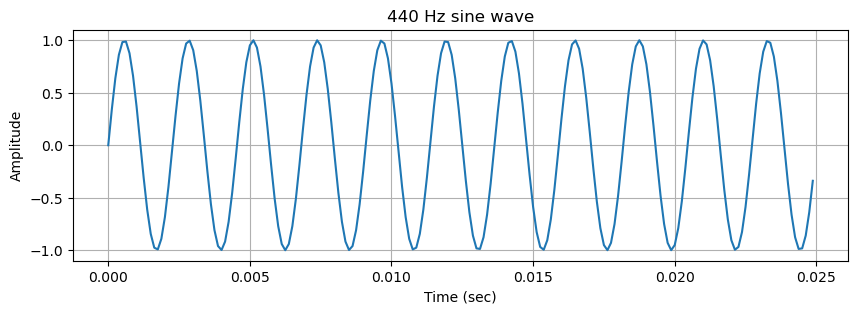

In [2]:
sr = 8000          # sampling rate
duration = 1.0     # seconds
freq = 440         # 440 Hz: A note

t = np.arange(int(sr * duration)) / sr
x = np.sin(2 * np.pi * freq * t)

print("sampling rate:", sr)
print("duration:", duration, "sec")
print("number of samples:", len(x))

plt.plot(t[:200], x[:200])
plt.title("440 Hz sine wave")
plt.xlabel("Time (sec)")
plt.ylabel("Amplitude")
plt.show()

display(Audio(x, rate=sr))


## 1-1. 샘플링 레이트 바꿔보기

같은 440 Hz 소리를 여러 샘플링 레이트로 만들어 봅니다.
소리의 길이는 모두 1초이지만, 저장되는 숫자의 개수는 달라집니다.

핵심 관계는 아래와 같습니다.

$$
N = f_s 	imes T
$$

- `sr_test`: $f_s$
- `duration`: $T$
- `len(x_test)`: $N$

440 Hz 사인파의 한 주기는 $T_0 = 1/440$초입니다.
한 주기를 몇 개의 점으로 표현하는지는 대략 $f_s / 440$으로 볼 수 있습니다. 따라서 `sr_test`가 커질수록 같은 파형을 더 많은 점으로 그리게 됩니다.



sr = 4000 Hz / samples = 4000


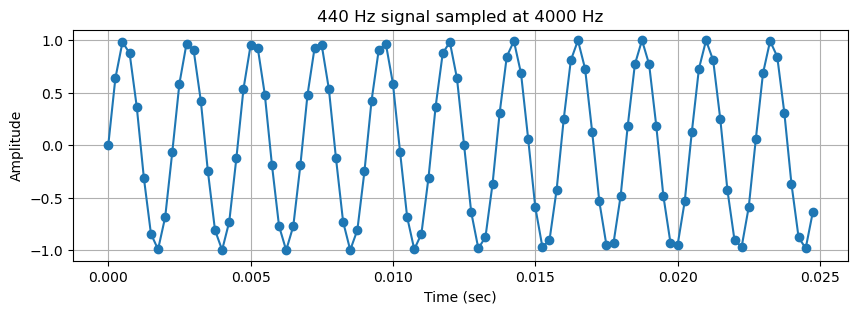

sr = 8000 Hz / samples = 8000


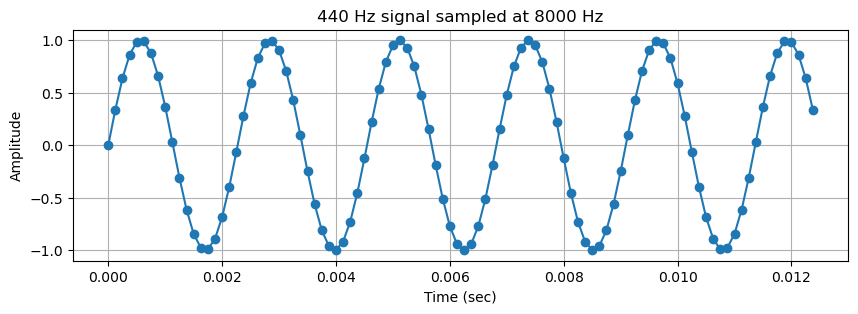

sr = 16000 Hz / samples = 16000


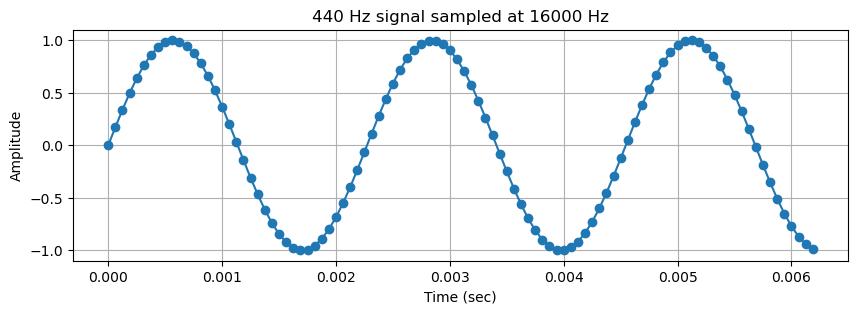

In [3]:
for sr_test in [4000, 8000, 16000]:
    t_test = np.arange(int(sr_test * duration)) / sr_test
    x_test = np.sin(2 * np.pi * freq * t_test)

    print("sr =", sr_test, "Hz / samples =", len(x_test))
    plt.plot(t_test[:100], x_test[:100], marker="o")
    plt.title(f"440 Hz signal sampled at {sr_test} Hz")
    plt.xlabel("Time (sec)")
    plt.ylabel("Amplitude")
    plt.show()

    display(Audio(x_test, rate=sr_test))


<details>
<summary>보고서에 적을 것</summary>

1. 샘플링 레이트가 4000, 8000, 16000 Hz일 때 샘플 개수는 각각 몇 개인가요?
2. $N = f_s 	imes T$ 수식으로 계산한 값과 `len(x_test)`가 같은가요?
3. 샘플링 레이트가 커지면 그래프의 점은 더 촘촘해지나요, 듬성듬성해지나요?
4. 샘플링 레이트가 커지면 파일 크기는 보통 어떻게 될까요?

</details>



# 실습 2. 정규화와 양자화

정규화는 신호의 크기를 일정 범위로 맞추는 과정입니다.
양자화는 소수로 된 진폭 값을 정해진 단계로 반올림하는 과정입니다.

## 정규화

신호의 최대 절댓값이 너무 크면 재생하거나 저장할 때 clipping이 생길 수 있습니다.
그래서 가장 큰 절댓값이 1이 되도록 전체 신호를 나눕니다.

$$
x_{norm}[n] = rac{x[n]}{\max_n |x[n]|}
$$

코드에서는 `big_x`가 정규화 전 신호이고, `norm_x = big_x / np.max(np.abs(big_x))`가 위 수식에 해당합니다.
정규화 후에는 `np.max(np.abs(norm_x))`가 거의 1이 됩니다.

## 양자화

컴퓨터가 진폭을 저장할 때 무한히 정밀한 실수를 그대로 저장할 수는 없습니다.
비트 수 $b$가 정해지면 표현 가능한 단계 수가 제한됩니다.
이 노트북의 코드는 대략 아래 방식으로 양자화합니다.

$$
L = 2^{b-1} - 1, \qquad q[n] = rac{\mathrm{round}(x_{norm}[n]L)}{L}
$$

- `bits`: $b$
- `level`: $L$
- `q`: 양자화된 신호 $q[n]$

비트 수가 낮아지면 $L$이 작아지고, 진폭 단계가 듬성듬성해집니다. 그래서 그래프가 계단처럼 보이고, 소리에는 양자화 잡음이 더 잘 들릴 수 있습니다.

<details>
<summary>쉽게 이해하기</summary>

정규화는 소리의 최대 크기를 `-1`에서 `1` 사이로 맞추는 작업입니다.

양자화는 진폭을 몇 단계로 나누어 저장하는 작업입니다.
비트 수가 낮으면 단계가 적어져서 소리가 거칠어질 수 있습니다.

</details>



before normalization max: 3.5
after normalization max: 1.0


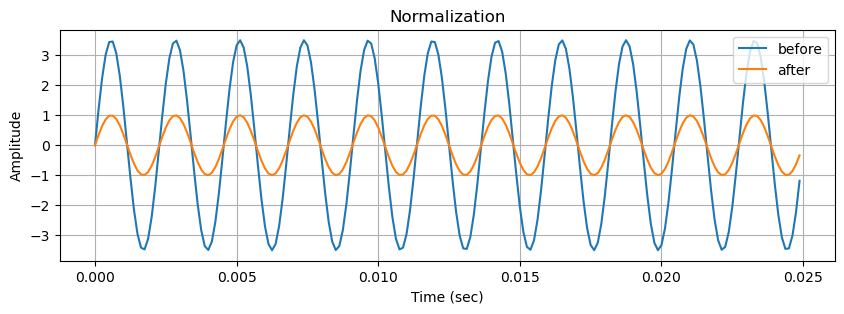

In [4]:
# 일부러 크기가 큰 신호를 만든 뒤 정규화합니다.
big_x = 3.5 * x
norm_x = big_x / np.max(np.abs(big_x))

print("before normalization max:", np.max(np.abs(big_x)))
print("after normalization max:", np.max(np.abs(norm_x)))

plt.plot(t[:200], big_x[:200], label="before")
plt.plot(t[:200], norm_x[:200], label="after")
plt.title("Normalization")
plt.xlabel("Time (sec)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()


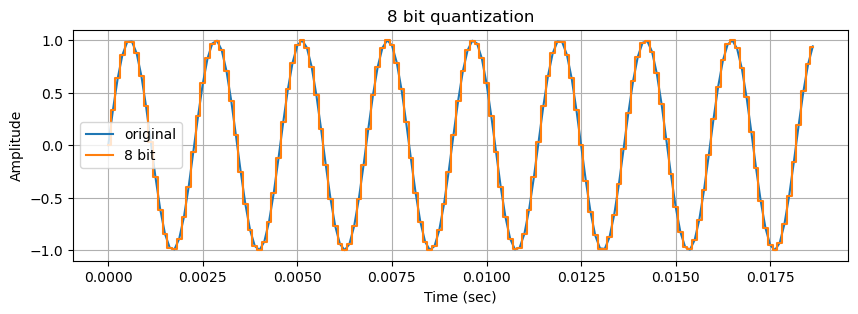

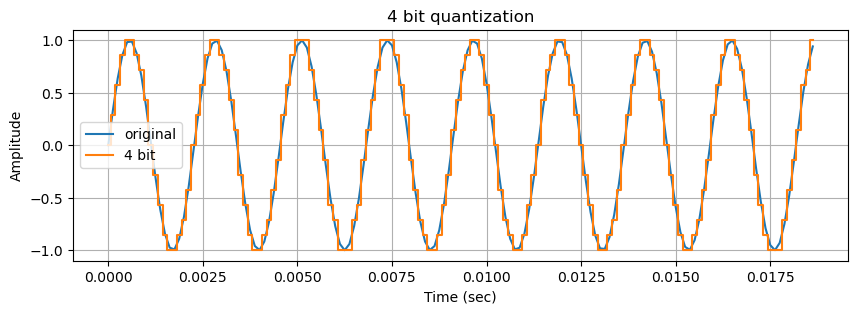

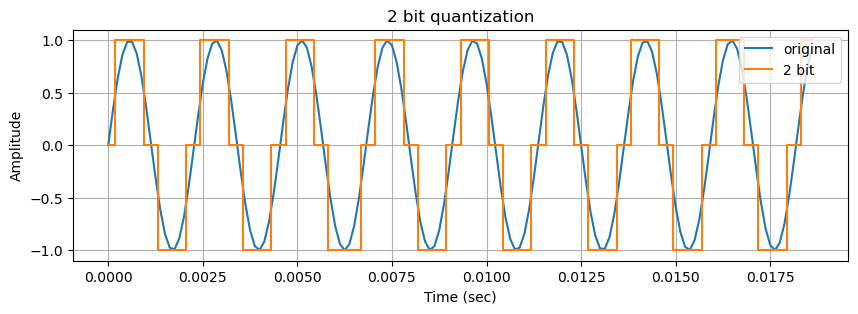

In [5]:
def quantize(signal, bits):
    level = 2 ** (bits - 1) - 1
    q = np.round(signal * level) / level
    return q


for bits in [8, 4, 2]:
    q = quantize(norm_x, bits)

    plt.plot(t[:150], norm_x[:150], label="original")
    plt.step(t[:150], q[:150], where="mid", label=f"{bits} bit")
    plt.title(f"{bits} bit quantization")
    plt.xlabel("Time (sec)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()

    display(Audio(q, rate=sr))


<details>
<summary>보고서에 적을 것</summary>

1. 정규화 전 최대 진폭과 정규화 후 최대 진폭을 적어보세요.
2. $x_{norm}[n] = x[n] / \max |x[n]|$ 수식에서 코드의 `big_x`와 `norm_x`가 각각 어디에 해당하나요?
3. 8 bit, 4 bit, 2 bit 중 어떤 그래프가 가장 계단처럼 보이나요?
4. 비트 수가 낮아질수록 소리는 어떻게 들리나요?

</details>



# 실습 3. FFT와 Spectrogram

FFT는 시간 영역의 신호를 주파수 영역으로 바꾸는 방법입니다.
시간 그래프에서는 신호가 어떻게 흔들리는지 보고, 주파수 그래프에서는 어떤 주파수가 들어 있는지 봅니다.

이번에 만드는 혼합 신호는 아래 수식에 해당합니다.

$$
x_{mix}[n] = 0.8\sin\left(2\pi \cdot 440 \cdot rac{n}{f_s}
ight) + 0.4\sin\left(2\pi \cdot 1000 \cdot rac{n}{f_s}
ight)
$$

코드에서는 `x_mix`가 이 신호입니다. 즉, 440 Hz 성분과 1000 Hz 성분을 동시에 가진 소리입니다.

DFT는 시간 신호 $x[n]$을 주파수 성분 $X[k]$로 바꿉니다.

$$
X[k] = \sum_{n=0}^{N-1} x[n]e^{-j2\pi kn/N}
$$

- `X = np.fft.rfft(x_mix)`: 실수 신호에 대한 FFT 결과 $X[k]$
- `freqs = np.fft.rfftfreq(...)`: 각 $k$가 몇 Hz인지 알려주는 주파수 축
- `magnitude = np.abs(X)`: 복소수 FFT 결과의 크기 $|X[k]|$

주파수 bin의 실제 주파수는 대략 아래와 같습니다.

$$
f_k = rac{k f_s}{N}
$$

따라서 그래프에서 440 Hz와 1000 Hz 근처의 봉우리를 찾으면, 코드로 만든 두 사인파가 주파수 영역에서 확인된 것입니다.



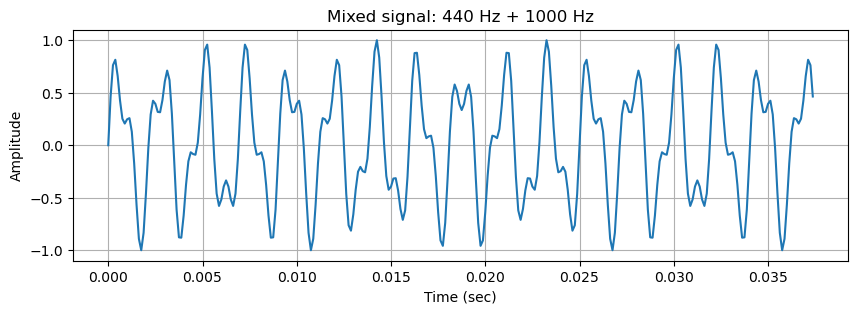

In [6]:
# 440 Hz와 1000 Hz를 섞은 신호를 만듭니다.
x_mix = (
    0.8 * np.sin(2 * np.pi * 440 * t)
    + 0.4 * np.sin(2 * np.pi * 1000 * t)
)
x_mix = x_mix / np.max(np.abs(x_mix))

plt.plot(t[:300], x_mix[:300])
plt.title("Mixed signal: 440 Hz + 1000 Hz")
plt.xlabel("Time (sec)")
plt.ylabel("Amplitude")
plt.show()

display(Audio(x_mix, rate=sr))


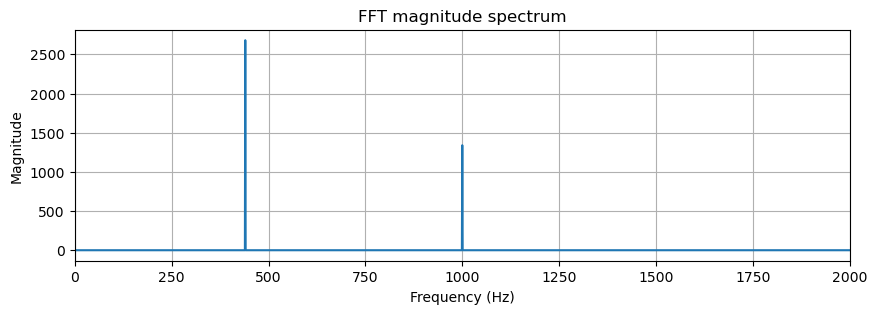

In [7]:
X = np.fft.rfft(x_mix)
freqs = np.fft.rfftfreq(len(x_mix), d=1 / sr)
magnitude = np.abs(X)

plt.plot(freqs, magnitude)
plt.title("FFT magnitude spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 2000)
plt.show()


<details>
<summary>FFT 그래프 해석</summary>

그래프에서 440 Hz 근처와 1000 Hz 근처에 큰 봉우리가 보이면 정상입니다.
이 봉우리는 신호 안에 해당 주파수 성분이 많이 들어 있다는 뜻입니다.

`x_mix`를 만들 때 440 Hz에는 계수 0.8, 1000 Hz에는 계수 0.4를 곱했습니다.
그래서 보통 440 Hz 봉우리가 1000 Hz 봉우리보다 더 크게 보입니다. 다만 앞에서 `x_mix = x_mix / np.max(...)`로 정규화를 했기 때문에, 그래프의 절댓값 자체보다 **어느 주파수에 봉우리가 생기는지**를 더 중요하게 보면 됩니다.

</details>



## 3-1. 시간이 지나면서 주파수가 바뀌는 신호

FFT는 전체 신호에 어떤 주파수가 들어 있는지는 보여주지만, 그 주파수가 언제 나타났는지는 잘 보여주지 못합니다.
그래서 짧은 구간으로 나누어 FFT를 여러 번 계산하는 spectrogram을 사용합니다.

Spectrogram은 STFT, 즉 Short-Time Fourier Transform의 크기를 그림으로 나타낸 것입니다.

$$
S[m,k] = \sum_{n=0}^{M-1} x[n + mH]w[n]e^{-j2\pi kn/M}
$$

- $M$: 한 번에 볼 frame 길이, 코드의 `frame_size`
- $H$: 다음 frame으로 이동하는 간격, 코드의 `hop_size`
- $w[n]$: window 함수, 코드의 `np.hanning(frame_size)`
- $m$: 몇 번째 시간 구간인지 나타내는 index
- $k$: 주파수 bin index

코드의 `simple_spectrogram`은 신호를 짧은 frame으로 자르고, 각 frame마다 FFT를 계산합니다.
그 결과 시간축과 주파수축을 동시에 가진 그림이 만들어집니다.

마지막에 사용하는 dB 변환은 아래와 같습니다.

$$
S_{dB} = 20\log_{10}(|S| + \epsilon)
$$

코드에서는 `S_db = 20 * np.log10(S + 1e-6)`입니다. `1e-6`은 로그 안이 0이 되는 것을 막기 위한 아주 작은 값입니다.



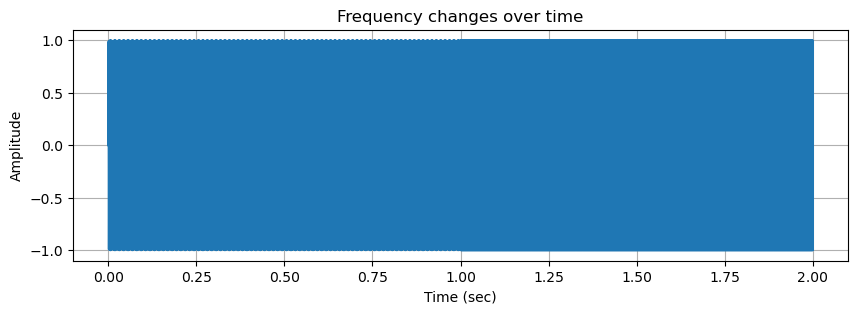

In [9]:
# 앞 1초는 440 Hz, 뒤 1초는 1000 Hz인 신호를 만듭니다.
sr2 = 8000
t1 = np.arange(sr2) / sr2
part1 = np.sin(2 * np.pi * 440 * t1)
part2 = np.sin(2 * np.pi * 1000 * t1)
x_change = np.concatenate([part1, part2])

display(Audio(x_change, rate=sr2))

plt.plot(np.arange(len(x_change)) / sr2, x_change)
plt.title("Frequency changes over time")
plt.xlabel("Time (sec)")
plt.ylabel("Amplitude")
plt.show()


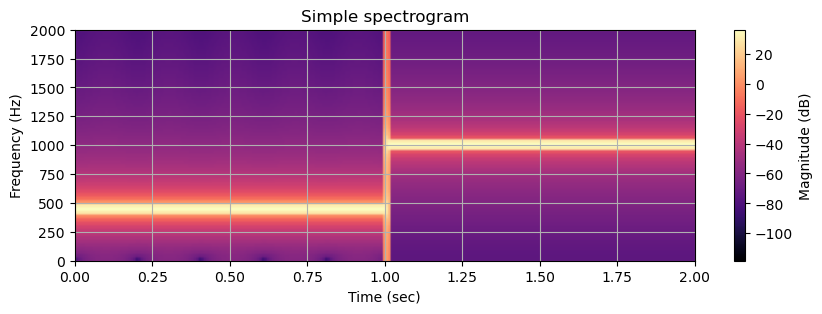

In [10]:
def simple_spectrogram(signal, sr, frame_size=256, hop_size=64):
    window = np.hanning(frame_size)
    specs = []

    for start in range(0, len(signal) - frame_size, hop_size):
        frame = signal[start:start + frame_size] * window
        spectrum = np.abs(np.fft.rfft(frame))
        specs.append(spectrum)

    specs = np.array(specs).T
    return specs


S = simple_spectrogram(x_change, sr2)
S_db = 20 * np.log10(S + 1e-6)

plt.imshow(
    S_db,
    origin="lower",
    aspect="auto",
    extent=[0, len(x_change) / sr2, 0, sr2 / 2],
    cmap="magma",
)
plt.colorbar(label="Magnitude (dB)")
plt.title("Simple spectrogram")
plt.xlabel("Time (sec)")
plt.ylabel("Frequency (Hz)")
plt.ylim(0, 2000)
plt.show()


<details>
<summary>보고서에 적을 것</summary>

1. FFT 그래프에서 큰 봉우리는 몇 Hz 근처에 있나요?
2. $f_k = kf_s/N$ 수식에서 `freqs` 배열은 어떤 역할을 하나요?
3. Spectrogram에서 0~1초 구간과 1~2초 구간의 주파수는 어떻게 달라지나요?
4. 시간 그래프만 볼 때와 spectrogram을 볼 때, 어떤 그림이 주파수 변화를 더 잘 보여주나요?

</details>



# 마지막 Chapter. GitHub에 실습 파일 올리는 방법

아래 내용은 설명입니다. 노트북 코드 셀에서 실행하는 것이 아니라, **터미널**에서 한 줄씩 입력합니다.
여기서는 너무 많은 Git 기능을 다루지 않고, 과제 파일을 GitHub에 올릴 때 꼭 필요한 흐름만 봅니다.

<details>
<summary>0. Git과 GitHub의 차이</summary>

- Git: 내 컴퓨터에서 파일 변경 기록을 관리하는 도구입니다.
- GitHub: Git으로 만든 기록을 인터넷 저장소에 올려두는 서비스입니다.

즉, `git commit`까지는 내 컴퓨터 안의 기록이고, `git push`를 해야 GitHub 웹사이트에 올라갑니다.

</details>

<details>
<summary>1. 꼭 알아야 할 stage 개념</summary>

Git은 파일을 바로 GitHub에 올리지 않습니다. 중간에 **stage**라는 준비 공간을 거칩니다.

```text
Working directory  ->  Staging area  ->  Local repository  ->  GitHub remote
파일 수정/저장          git add           git commit            git push
```

각 단계의 의미는 다음과 같습니다.

- Working directory: 실제 파일을 수정하고 저장하는 현재 폴더입니다.
- Staging area: 다음 commit에 넣을 파일을 고르는 준비 공간입니다.
- Local repository: `commit`으로 저장된 내 컴퓨터 안의 Git 기록입니다.
- GitHub remote: `push` 후 GitHub 웹페이지에서 보이는 원격 저장소입니다.

중요한 점은 **파일을 저장했다고 commit에 들어가는 것이 아니라는 점**입니다.
수정한 파일을 commit에 포함하려면 반드시 `git add`로 stage에 올려야 합니다.

```bash
git status
git add DSP_basic_practice.ipynb
git status
git commit -m "Update DSP practice"
git push
```

첫 번째 `git status`에서는 수정된 파일이 보이고, `git add` 뒤의 `git status`에서는 그 파일이 commit 준비 상태로 바뀐 것을 확인할 수 있습니다.

</details>

<details>
<summary>2. GitHub repository 만들기</summary>

1. GitHub에 로그인합니다.
2. 오른쪽 위 `+` 버튼을 누릅니다.
3. `New repository`를 선택합니다.
4. Repository name을 입력합니다. 예: `dsp-practice`
5. Public 또는 Private을 선택합니다.
6. 처음 올리는 경우 `Add a README file`은 체크하지 않는 편이 쉽습니다.
7. `Create repository`를 누릅니다.

repository를 만들면 아래와 비슷한 주소가 나옵니다.

```bash
https://github.com/본인아이디/dsp-practice.git
```

이 주소는 사람마다 다릅니다. 반드시 본인 GitHub 주소를 사용해야 합니다.

</details>

<details>
<summary>3. 터미널에서 내 실습 폴더로 이동하기</summary>

먼저 터미널을 열고, 실습 파일이 있는 폴더로 이동합니다.

예시:

```bash
cd "/Users/limhyeongsoo/Documents/문서 - 임형수의 MacBook Air/중앙대학교_AI/수업자료/군 장병(음성처리)/Code"
```

학생들은 위 경로를 그대로 쓰면 안 됩니다.
자기 컴퓨터에서 `DSP_basic_practice.ipynb`가 들어 있는 폴더 경로로 바꿔야 합니다.

현재 폴더에 어떤 파일이 있는지 확인하려면 아래 명령어를 입력합니다.

```bash
ls
```

</details>

<details>
<summary>4. 처음 한 번 GitHub에 올리는 명령어</summary>

아래 명령어를 순서대로 입력합니다.

```bash
git init
git status
git add DSP_basic_practice.ipynb
git commit -m "Add DSP practice notebook"
git branch -M main
git remote add origin https://github.com/본인아이디/dsp-practice.git
git push -u origin main
```

각 명령어의 의미는 다음과 같습니다.

- `git init`: 현재 폴더를 Git으로 관리하기 시작합니다.
- `git status`: 현재 파일 상태를 확인합니다. 수정만 된 파일인지, stage에 올라간 파일인지 볼 수 있습니다.
- `git add DSP_basic_practice.ipynb`: 이 파일을 staging area에 올립니다. 여러 파일을 한꺼번에 올릴 때는 `git add .`도 쓸 수 있습니다.
- `git commit -m "..."`: stage에 올라간 파일들을 하나의 기록으로 저장합니다.
- `git branch -M main`: branch 이름을 `main`으로 맞춥니다.
- `git remote add origin ...`: 내 폴더와 GitHub repository를 연결합니다.
- `git push -u origin main`: 내 컴퓨터의 commit을 GitHub에 업로드합니다.

</details>

<details>
<summary>5. 수정한 뒤 다시 올리는 명령어</summary>

처음 업로드를 끝낸 뒤에는 보통 아래 흐름만 반복하면 됩니다.

```bash
git status
git add DSP_basic_practice.ipynb
git commit -m "Update DSP practice notebook"
git push
```

상태를 이해하는 기준은 간단합니다.

- `Changes not staged for commit`: 파일은 수정됐지만 아직 stage에 올라가지 않았습니다. `git add`가 필요합니다.
- `Changes to be committed`: stage에 올라갔고 commit 준비가 됐습니다.
- `nothing to commit, working tree clean`: 수정된 내용이 남아 있지 않습니다.

잘못 stage에 올린 파일을 빼고 싶을 때는 아래처럼 합니다. 파일 내용은 지워지지 않고, stage에서만 내려옵니다.

```bash
git restore --staged 파일명
```

</details>

<details>
<summary>6. 자주 나는 오류</summary>

`fatal: remote origin already exists`

이미 GitHub 주소가 등록되어 있다는 뜻입니다. 현재 주소를 확인합니다.

```bash
git remote -v
```

주소를 바꾸려면 아래처럼 입력합니다.

```bash
git remote set-url origin https://github.com/본인아이디/dsp-practice.git
```

`src refspec main does not match any`

아직 commit을 만들지 않았거나 branch 이름이 다를 때 자주 나옵니다.

```bash
git add DSP_basic_practice.ipynb
git commit -m "First commit"
git branch -M main
git push -u origin main
```

`rejected` 또는 `non-fast-forward`

GitHub에 있는 내용과 내 컴퓨터 내용이 달라서 push가 거절된 것입니다.
먼저 GitHub 내용을 받아온 뒤 다시 push합니다.

```bash
git pull --rebase origin main
git push
```

</details>

<details>
<summary>7. 업로드 확인하기</summary>

GitHub repository 웹페이지를 새로고침합니다.
`DSP_basic_practice.ipynb` 파일이 보이면 업로드가 된 것입니다.

마지막으로 터미널에서 아래 명령어를 입력합니다.

```bash
git status
```

`nothing to commit, working tree clean`이라고 나오면 현재 변경 사항이 모두 정리된 상태입니다.

</details>

